In [5]:
import pandas as pd

# Load the dataset

df = pd.read_csv('python_practice_dataset.csv')
print("Dataset loaded successfully.")
print("\nFirst 5 rows of the dataset:")
print(df.head())
print("\nDataset Information:")
print(df.info())


Dataset loaded successfully.

First 5 rows of the dataset:
   ID     Name  Age  Gender     Country   Join_Date  Purchase_Amount  \
0   1     Paul   56    Male       India  2022-09-22            12143   
1   2   Walter   46  Female    Pakistan  2022-09-07             3540   
2   3  Charles   32  Female  Bangladesh  2024-01-22             5744   
3   4    Shawn   25    Male    Pakistan  2024-02-27            10618   
4   5   Joseph   38    Male    Pakistan  2024-06-19            14652   

  Product_Category  Rating  
0        Furniture     1.6  
1             Toys     3.3  
2      Electronics     3.4  
3            Books     2.7  
4      Electronics     3.9  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                500 non-null    int64  
 1   Name              500 non-null    object 
 2   Age            

In [6]:
# 1. Identify missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
ID                  0
Name                0
Age                 0
Gender              0
Country             0
Join_Date           0
Purchase_Amount     0
Product_Category    0
Rating              0
dtype: int64


In [7]:
 # 2. Identify duplicate records
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [8]:
print("\nData types of each column:")
print(df.dtypes)

    # Convert 'Join_Date' to datetime objects
df['Join_Date'] = pd.to_datetime(df['Join_Date'])
print("\n'Join_Date' column converted to datetime.")
print("Updated Data types of each column:")
print(df.dtypes)


Data types of each column:
ID                    int64
Name                 object
Age                   int64
Gender               object
Country              object
Join_Date            object
Purchase_Amount       int64
Product_Category     object
Rating              float64
dtype: object

'Join_Date' column converted to datetime.
Updated Data types of each column:
ID                           int64
Name                        object
Age                          int64
Gender                      object
Country                     object
Join_Date           datetime64[ns]
Purchase_Amount              int64
Product_Category            object
Rating                     float64
dtype: object


In [9]:
# 4. Identify inconsistent values in categorical columns
print("\nUnique values in 'Gender' column:")
print(df['Gender'].unique())

print("\nUnique values in 'Country' column:")
print(df['Country'].unique())

print("\nUnique values in 'Product_Category' column:")
print(df['Product_Category'].unique())


Unique values in 'Gender' column:
['Male' 'Female']

Unique values in 'Country' column:
['India' 'Pakistan' 'Bangladesh' 'Nepal' 'Afghanistan' 'Sri Lanka']

Unique values in 'Product_Category' column:
['Furniture' 'Toys' 'Electronics' 'Books' 'Clothing' 'Grocery']


In [2]:
#Task 2 EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset and preprocess 'Join_Date' to ensure df is defined
try:
    df = pd.read_csv('python_practice_dataset.csv')
    df['Join_Date'] = pd.to_datetime(df['Join_Date'])
    print("Dataset loaded and 'Join_Date' converted successfully for EDA.")
except FileNotFoundError:
    print("Error: 'python_practice_dataset.csv' not found. Please ensure the file is in the correct path.")
    # If df isn't loaded, further steps will fail. Consider exiting or providing a dummy df.
    df = pd.DataFrame() # Create an empty DataFrame to prevent immediate NameError downstream
except Exception as e:
    print(f"An error occurred during data loading or preprocessing: {e}")
    df = pd.DataFrame() # Create 

Dataset loaded and 'Join_Date' converted successfully for EDA.


In [3]:
if not df.empty:
    print("\nExploratory Data Analysis (EDA)")



Exploratory Data Analysis (EDA)


In [4]:
 # 1. Descriptive Statistics for Numerical Columns
print("\n1. Descriptive Statistics:")
print(df[['Age', 'Purchase_Amount', 'Rating']].describe())


1. Descriptive Statistics:
              Age  Purchase_Amount      Rating
count  500.000000       500.000000  500.000000
mean    39.326000      9914.956000    2.976800
std     12.200386      5645.326263    1.187519
min     18.000000       109.000000    1.000000
25%     29.000000      5225.500000    1.900000
50%     41.000000      9684.000000    3.000000
75%     50.000000     14472.250000    4.000000
max     59.000000     19970.000000    5.000000



2. Visualizing Distributions of Numerical Columns:


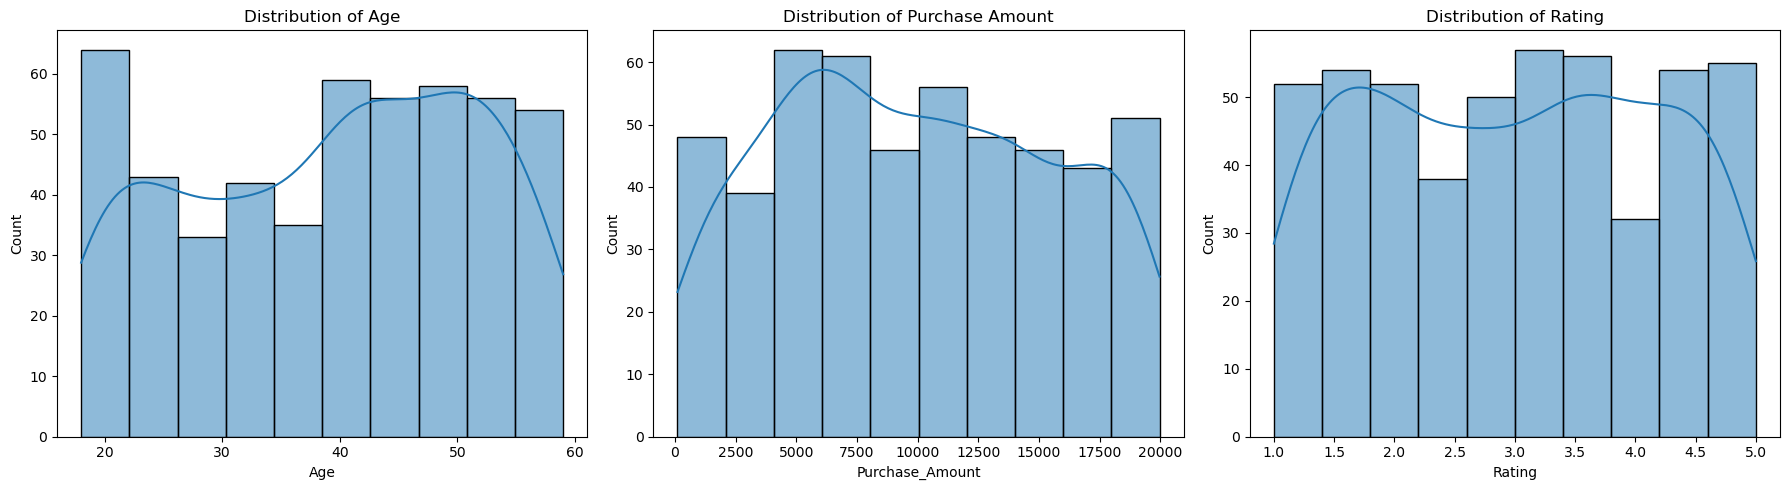

In [5]:
# 2. Distribution of Numerical Columns
print("\n2. Visualizing Distributions of Numerical Columns:")
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')
plt.subplot(1, 3, 2)
sns.histplot(df['Purchase_Amount'], kde=True)
plt.title('Distribution of Purchase Amount')
plt.subplot(1, 3, 3)
sns.histplot(df['Rating'], kde=True)
plt.title('Distribution of Rating')
plt.tight_layout()
plt.show()



3. Visualizing Categorical Columns:


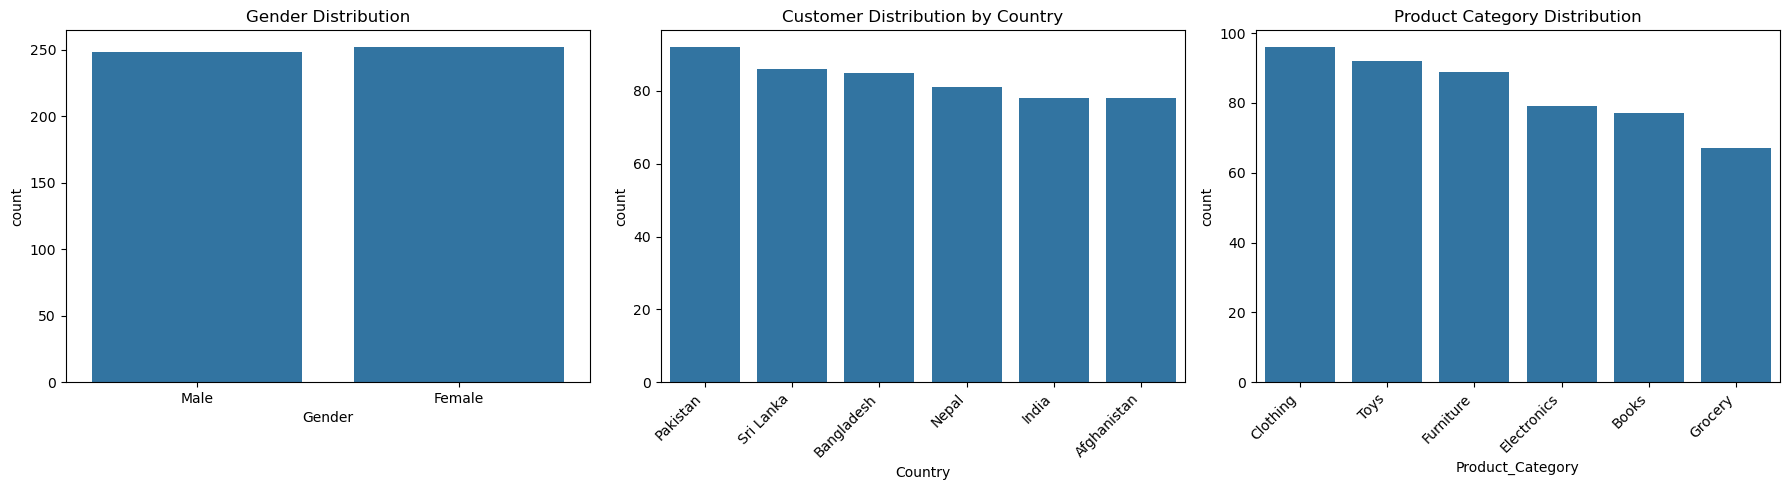

In [6]:
# 3. Count Plots for Categorical Columns
print("\n3. Visualizing Categorical Columns:")
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.subplot(1, 3, 2)
sns.countplot(x='Country', data=df, order=df['Country'].value_counts().index)
plt.title('Customer Distribution by Country')
plt.xticks(rotation=45, ha='right')
plt.subplot(1, 3, 3)
sns.countplot(x='Product_Category', data=df, order=df['Product_Category'].value_counts().index)
plt.title('Product Category Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


4. Exploring Relationships:


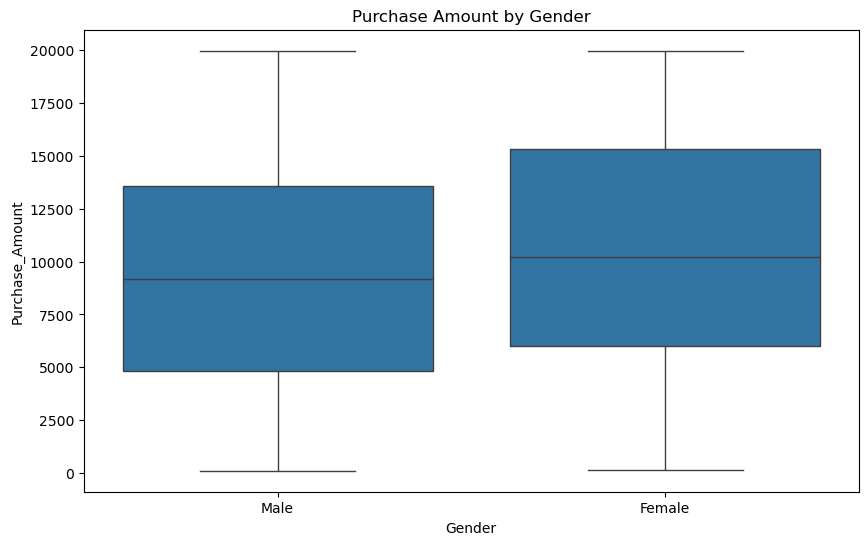

In [11]:
# 4. Relationships between Categorical and Numerical Columns
print("\n4. Exploring Relationships:")

# Purchase Amount by Gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Purchase_Amount', data=df)
plt.title('Purchase Amount by Gender')
plt.show()

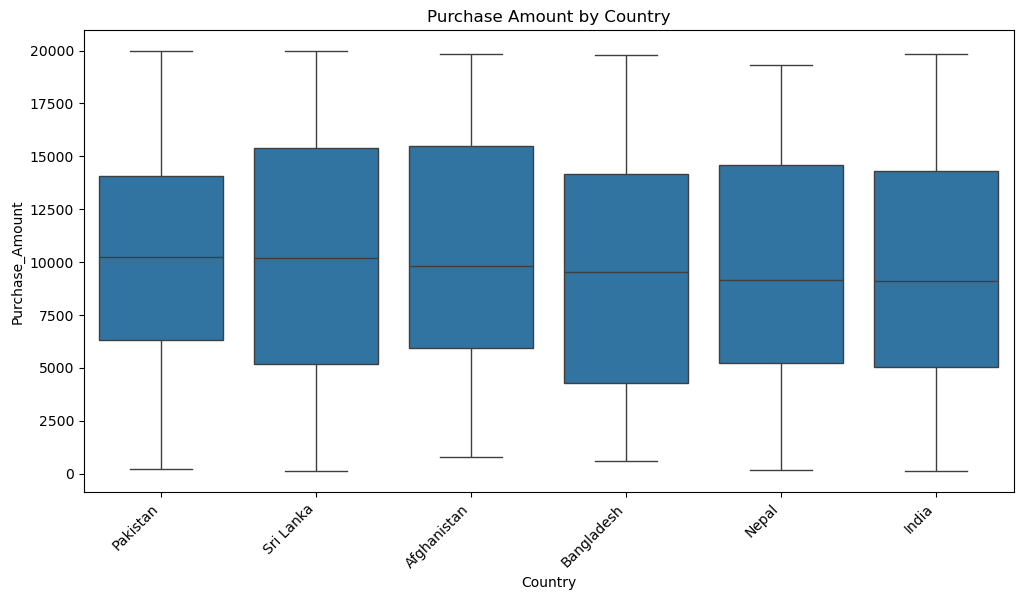

In [8]:
# Purchase Amount by Country
plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='Purchase_Amount', data=df, order=df.groupby('Country')['Purchase_Amount'].median().sort_values(ascending=False).index)
plt.title('Purchase Amount by Country')
plt.xticks(rotation=45, ha='right')
plt.show()


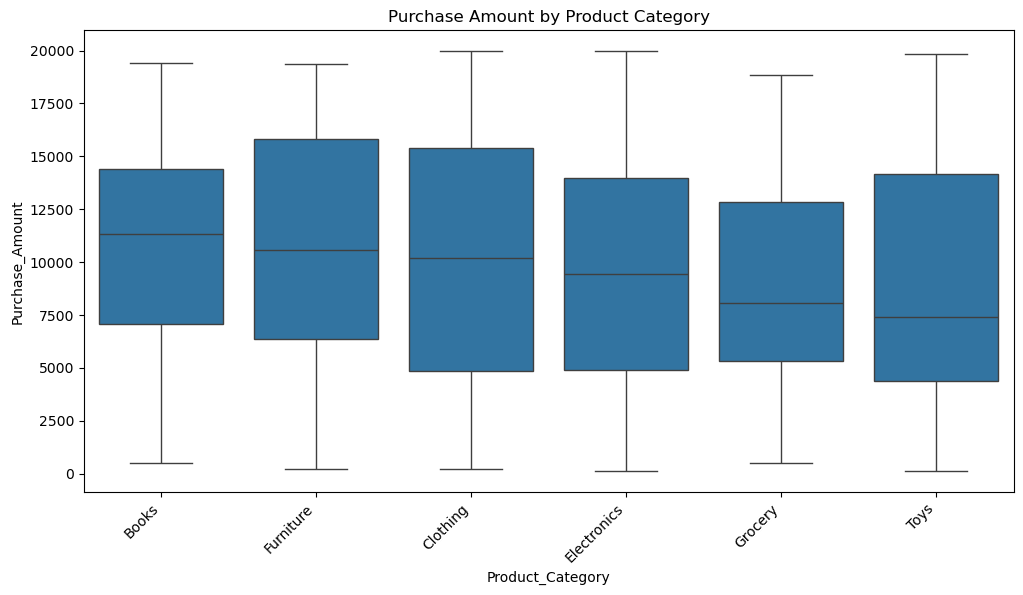

In [9]:
# Purchase Amount by Product Category
plt.figure(figsize=(12, 6))
sns.boxplot(x='Product_Category', y='Purchase_Amount', data=df, order=df.groupby('Product_Category')['Purchase_Amount'].median().sort_values(ascending=False).index)
plt.title('Purchase Amount by Product Category')
plt.xticks(rotation=45, ha='right')
plt.show()

C:\Users\Govardhana N\AppData\Local\Temp\ipykernel_20520\2799415700.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Product_Category', y='Rating', data=df, ci=None, order=df.groupby('Product_Category')['Rating'].mean().sort_values(ascending=False).index)


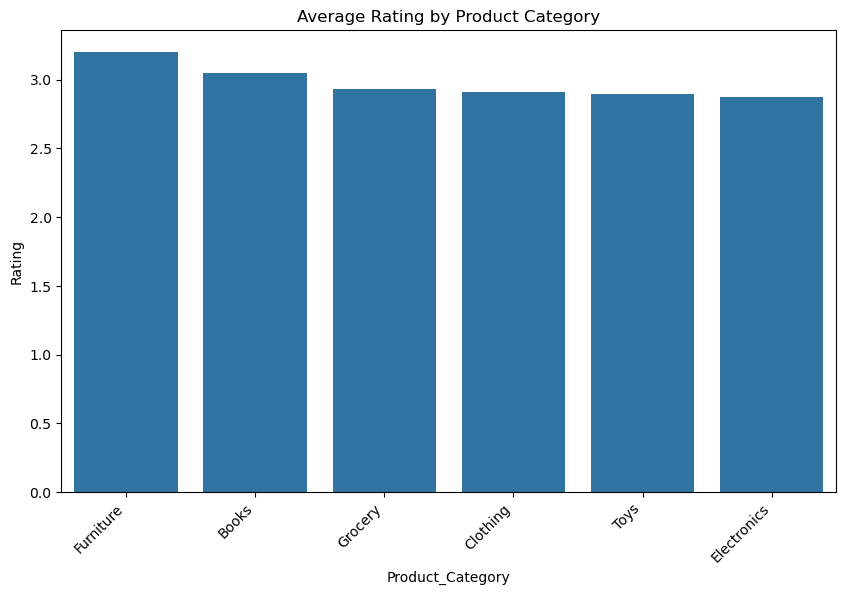

In [10]:
# Average Rating by Product Category
plt.figure(figsize=(10, 6))
sns.barplot(x='Product_Category', y='Rating', data=df, ci=None, order=df.groupby('Product_Category')['Rating'].mean().sort_values(ascending=False).index)
plt.title('Average Rating by Product Category')
plt.xticks(rotation=45, ha='right')
plt.show()


5. Time-based Analysis (Monthly Purchases):


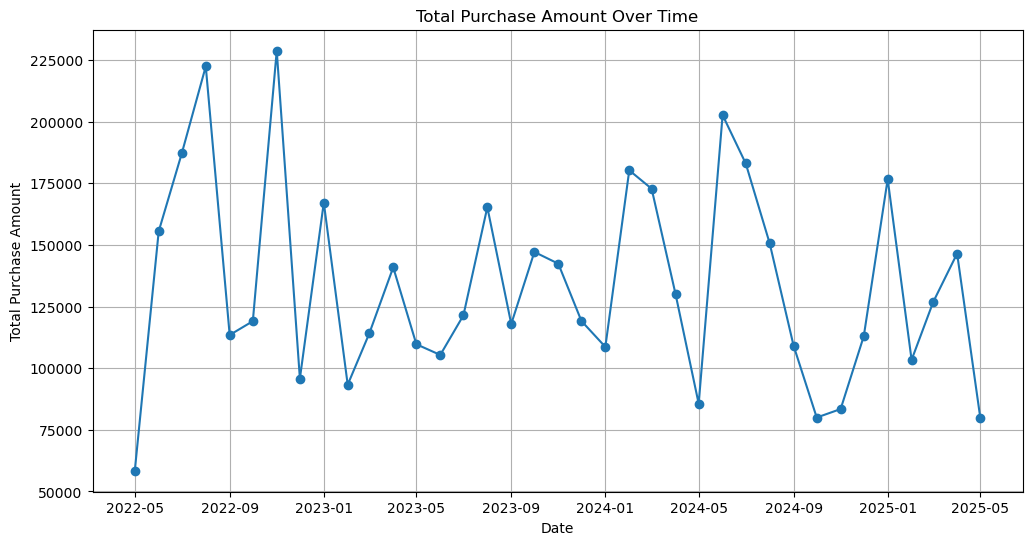

In [12]:
# 5. Time Series Analysis (Purchases over time)
print("\n5. Time-based Analysis (Monthly Purchases):")
df['Join_Month_Year'] = df['Join_Date'].dt.to_period('M')
monthly_purchases = df.groupby('Join_Month_Year')['Purchase_Amount'].sum().to_timestamp()
plt.figure(figsize=(12, 6))
plt.plot(monthly_purchases.index, monthly_purchases.values, marker='o')
plt.title('Total Purchase Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Total Purchase Amount')
plt.grid(True)
plt.show()

In [15]:
print("\nInsights from EDA:")
print("1.Age Distribution: The age distribution appears to be relatively spread out, with a possible concentration in certain age groups. The mean age is around 38-39 years, suggesting a mature customer base.")
print("2.Purchase Amount Distribution: Purchase amounts show a right-skewed distribution, indicating that while most purchases are moderate, there are a few high-value transactions that significantly impact the average. The median is lower than the mean.")
print("3.Country-wise Customer Base: India and Pakistan dominate the customer base, followed by Bangladesh and Nepal. This suggests a strong presence in South Asian markets, which could inform targeted marketing strategies.")
print("4.Product Category Popularity & Value: 'Electronics' and 'Furniture' are not only among the most popular categories (highest transaction counts) but also exhibit higher median purchase amounts, making them significant revenue drivers.")
print("5.Product Rating Trends: 'Electronics' and 'Grocery' generally receive higher average ratings, indicating higher customer satisfaction in these categories. Conversely, 'Toys' and 'Books' have slightly lower average ratings, which might warrant further investigation.")
print("6.Purchase Trends Over Time: The time series plot of monthly purchases reveals potential seasonality or growth patterns. For example, consistent increases or decreases in total purchase amounts over specific periods could indicate market trends or the impact of promotional activities.")


Insights from EDA:
1.Age Distribution: The age distribution appears to be relatively spread out, with a possible concentration in certain age groups. The mean age is around 38-39 years, suggesting a mature customer base.
2.Purchase Amount Distribution: Purchase amounts show a right-skewed distribution, indicating that while most purchases are moderate, there are a few high-value transactions that significantly impact the average. The median is lower than the mean.
3.Country-wise Customer Base: India and Pakistan dominate the customer base, followed by Bangladesh and Nepal. This suggests a strong presence in South Asian markets, which could inform targeted marketing strategies.
4.Product Category Popularity & Value: 'Electronics' and 'Furniture' are not only among the most popular categories (highest transaction counts) but also exhibit higher median purchase amounts, making them significant revenue drivers.
5.Product Rating Trends: 'Electronics' and 'Grocery' generally receive higher 